In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("/content/drive/MyDrive/antibiotic_resistance_tracking.csv")

In [3]:
print(df.shape)
print(df["Meropenem"].value_counts())

(2200, 12)
Meropenem
Resistant       755
Intermediate    737
Sensitive       708
Name: count, dtype: int64


In [4]:
df["Meropenem_binary"] = df["Meropenem"].apply(
    lambda x: 1 if x == "Resistant" else 0
)

print(df["Meropenem_binary"].value_counts())
print(f"Resistant: {df['Meropenem_binary'].sum()}")
print(f"Non-Resistant: {(df['Meropenem_binary'] == 0).sum()}")

Meropenem_binary
0    1445
1     755
Name: count, dtype: int64
Resistant: 755
Non-Resistant: 1445


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        2199 non-null   object
 1   Age               2200 non-null   int64 
 2   Gender            2200 non-null   object
 3   Specimen_Type     2200 non-null   object
 4   Amoxicillin       2200 non-null   object
 5   Ciprofloxacin     2200 non-null   object
 6   Meropenem         2200 non-null   object
 7   Vancomycin        2200 non-null   object
 8   Colistin          2200 non-null   object
 9   Test_Method       2200 non-null   object
 10  Resistance_Genes  1763 non-null   object
 11  Outcome           2200 non-null   object
 12  Meropenem_binary  2200 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 223.6+ KB


In [6]:
features = [
    "Age",
    "Specimen_Type",
    "Amoxicillin",
    "Ciprofloxacin",
    "Vancomycin",
    "Colistin",
    "Resistance_Genes"
]
df[features].dtypes

,0
Age,int64
Specimen_Type,object
Amoxicillin,object
Ciprofloxacin,object
Vancomycin,object
Colistin,object
Resistance_Genes,object


In [7]:
df_encoded = pd.get_dummies(df[features], columns=[
    "Specimen_Type",
    "Amoxicillin",
    "Ciprofloxacin",
    "Vancomycin",
    "Colistin",
    "Resistance_Genes"
])

print(df_encoded.shape)
print(df_encoded.head())

(2200, 22)
   Age  Specimen_Type_Blood  Specimen_Type_Sputum  Specimen_Type_Stool  \
0   36                 True                 False                False   
1   59                 True                 False                False   
2   13                False                 False                False   
3    4                False                  True                False   
4   51                False                 False                False   

   Specimen_Type_Urine  Specimen_Type_Wound swab  Amoxicillin_Intermediate  \
0                False                     False                      True   
1                False                     False                      True   
2                 True                     False                      True   
3                False                     False                      True   
4                 True                     False                     False   

   Amoxicillin_Resistant  Amoxicillin_Sensitive  Ciprofloxacin_Intermediate

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded
y = df["Meropenem_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1760, 22)
Test set: (440, 22)


In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)


lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)

print("Model trained successfully!")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Model trained successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 1 1 0 1 0 0 0]


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      1.00      0.80       291
           1       0.00      0.00      0.00       149

    accuracy                           0.66       440
   macro avg       0.33      0.50      0.40       440
weighted avg       0.44      0.66      0.53       440

[[291   0]
 [149   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.54      0.60       291
           1       0.35      0.49      0.41       149

    accuracy                           0.53       440
   macro avg       0.51      0.52      0.51       440
weighted avg       0.57      0.53      0.54       440

[[158 133]
 [ 76  73]]


In [12]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                  class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Model trained successfully!")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Model trained successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
First 10 actual values: [0 0 0 1 1 0 1 0 0 0]


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.69      0.84      0.76       291
           1       0.47      0.28      0.35       149

    accuracy                           0.65       440
   macro avg       0.58      0.56      0.55       440
weighted avg       0.62      0.65      0.62       440

[[243  48]
 [107  42]]


In [14]:
df.shape

(2200, 13)

In [15]:
isolates = pd.read_csv("/content/drive/MyDrive/amr_watch_nigeria_isolates.csv")
ast_results = pd.read_csv("/content/drive/MyDrive/amr_watch_nigeria_ast_results.csv")

print(isolates.shape)
print(ast_results.shape)
print(isolates["carbapenem_resistant"].value_counts())

(30000, 19)
(332235, 6)
carbapenem_resistant
No     15897
Yes     5704
Name: count, dtype: int64


In [16]:
print(isolates["carbapenem_resistant"].value_counts(dropna=False))

carbapenem_resistant
No     15897
NaN     8399
Yes     5704
Name: count, dtype: int64


In [17]:
isolates_cr = isolates.dropna(subset=["carbapenem_resistant"])
print(isolates_cr.shape)
print(isolates_cr["carbapenem_resistant"].value_counts())

(21601, 19)
carbapenem_resistant
No     15897
Yes     5704
Name: count, dtype: int64


In [18]:
isolates_cr["target"] = isolates_cr["carbapenem_resistant"].map({"Yes": 1, "No": 0})
print(isolates_cr["target"].value_counts())

target
0    15897
1     5704
Name: count, dtype: int64


/tmp/ipykernel_13786/2872417556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolates_cr["target"] = isolates_cr["carbapenem_resistant"].map({"Yes": 1, "No": 0})


In [19]:
features = [
    "patient_age",
    "specimen_type",
    "organism",
    "MRSA_status",
    "ESBL_status",
    "ward_type",
    "facility_type",
    "zone",
    "year"
]

target = "target"


In [20]:
print(isolates_cr[features].dtypes)
print(isolates_cr[features].isnull().sum())

patient_age       int64
specimen_type    object
organism         object
MRSA_status      object
ESBL_status      object
ward_type        object
facility_type    object
zone             object
year              int64
dtype: object
patient_age          0
specimen_type        0
organism             0
MRSA_status      21601
ESBL_status       5093
ward_type            0
facility_type        0
zone                 0
year                 0
dtype: int64


In [21]:
print(isolates_cr["MRSA_status"].value_counts(dropna=False))
print(isolates_cr["ESBL_status"].value_counts(dropna=False))

MRSA_status
NaN    21601
Name: count, dtype: int64
ESBL_status
Positive    11112
Negative     5396
NaN          5093
Name: count, dtype: int64


In [22]:

features = [
    "patient_age",
    "specimen_type",
    "organism",
    "ESBL_status",
    "ward_type",
    "facility_type",
    "zone",
    "year"
]


isolates_cr["ESBL_status"] = isolates_cr["ESBL_status"].fillna("Unknown")

print(isolates_cr[features].isnull().sum())

patient_age      0
specimen_type    0
organism         0
ESBL_status      0
ward_type        0
facility_type    0
zone             0
year             0
dtype: int64


/tmp/ipykernel_13786/1642107652.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolates_cr["ESBL_status"] = isolates_cr["ESBL_status"].fillna("Unknown")


In [23]:
df_encoded = pd.get_dummies(isolates_cr[features], columns=[
    "specimen_type",
    "organism",
    "ESBL_status",
    "ward_type",
    "facility_type",
    "zone"
],dtype=int)
print(df_encoded.shape)
print(df_encoded.head())

(21601, 37)
   patient_age  year  specimen_type_Blood  specimen_type_CSF  \
0           35  2025                    0                  0   
1            0  2025                    1                  0   
2           16  2024                    0                  0   
4           42  2024                    0                  0   
5           15  2024                    1                  0   

   specimen_type_High vaginal  specimen_type_Pus  specimen_type_Sputum  \
0                           0                  0                     0   
1                           0                  0                     0   
2                           0                  0                     0   
4                           0                  0                     0   
5                           0                  0                     0   

   specimen_type_Stool  specimen_type_Urine  specimen_type_Wound swab  ...  \
0                    0                    1                         0  ...   
1 

In [24]:
from sklearn.model_selection import train_test_split

X_amr = df_encoded
y_amr= isolates_cr["target"]

X_train_amr, X_test_amr, y_train_amr, y_test_amr = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1760, 22)
Test set: (440, 22)


In [25]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.54      0.60       291
           1       0.35      0.49      0.41       149

    accuracy                           0.53       440
   macro avg       0.51      0.52      0.51       440
weighted avg       0.57      0.53      0.54       440

[[158 133]
 [ 76  73]]


In [26]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                  class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Model trained successfully!")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Model trained successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
First 10 actual values: [0 0 0 1 1 0 1 0 0 0]


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.84      0.76       291
           1       0.47      0.28      0.35       149

    accuracy                           0.65       440
   macro avg       0.58      0.56      0.55       440
weighted avg       0.62      0.65      0.62       440

[[243  48]
 [107  42]]


In [28]:
print(X_train.shape)
print(X_test.shape)

(1760, 22)
(440, 22)


In [29]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 1154, 1: 606}
After SMOTE: {0: 1154, 1: 1154}


In [30]:

lr_smote = LogisticRegression(random_state=42, max_iter=5000)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_lr_smote = lr_smote.predict(X_test)


rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_rf_smote = rf_smote.predict(X_test)

In [31]:
print("Logistic Regression + SMOTE:")
print(classification_report(y_test, y_pred_lr_smote))
print(confusion_matrix(y_test, y_pred_lr_smote))

print("\nRandom Forest + SMOTE:")
print(classification_report(y_test, y_pred_rf_smote))
print(confusion_matrix(y_test, y_pred_rf_smote))

Logistic Regression + SMOTE:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80       291
           1       1.00      0.01      0.01       149

    accuracy                           0.66       440
   macro avg       0.83      0.50      0.41       440
weighted avg       0.78      0.66      0.53       440

[[291   0]
 [148   1]]

Random Forest + SMOTE:
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       291
           1       0.40      0.33      0.36       149

    accuracy                           0.61       440
   macro avg       0.54      0.54      0.54       440
weighted avg       0.59      0.61      0.60       440

[[218  73]
 [100  49]]


In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=12692/4588,
    eval_metric="logloss",
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.68      0.61      0.65       291
           1       0.37      0.45      0.41       149

    accuracy                           0.56       440
   macro avg       0.53      0.53      0.53       440
weighted avg       0.58      0.56      0.57       440

[[178 113]
 [ 82  67]]


In [33]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True
)

nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

print(classification_report(y_test, y_pred_nn))
print(confusion_matrix(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.66      1.00      0.80       291
           1       0.00      0.00      0.00       149

    accuracy                           0.66       440
   macro avg       0.33      0.50      0.40       440
weighted avg       0.44      0.66      0.53       440

[[291   0]
 [149   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True
)

nn_model.fit(X_train_sm, y_train_sm)
y_pred_nn = nn_model.predict(X_test)

print(classification_report(y_test, y_pred_nn))
print(confusion_matrix(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.66      0.89      0.76       291
           1       0.30      0.09      0.13       149

    accuracy                           0.62       440
   macro avg       0.48      0.49      0.45       440
weighted avg       0.53      0.62      0.55       440

[[260  31]
 [136  13]]


In [35]:

y_pred_proba = lr_model.predict_proba(X_test)[:, 1]


for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_thresh = (y_pred_proba > threshold).astype(int)
    from sklearn.metrics import recall_score, precision_score, f1_score
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}, F1={f1:.2f}")

Threshold 0.5: Recall=0.49, Precision=0.35, F1=0.41
Threshold 0.4: Recall=0.99, Precision=0.34, F1=0.50
Threshold 0.3: Recall=1.00, Precision=0.34, F1=0.51
Threshold 0.2: Recall=1.00, Precision=0.34, F1=0.51


In [36]:
lr_model_amr = LogisticRegression(
    random_state=42,
    max_iter=5000,
    class_weight="balanced"
)

lr_model_amr.fit(X_train_amr, y_train_amr)
y_pred_amr = lr_model_amr.predict(X_test_amr)

print(classification_report(y_test_amr, y_pred_amr))

              precision    recall  f1-score   support

           0       0.68      0.54      0.60       291
           1       0.35      0.49      0.41       149

    accuracy                           0.53       440
   macro avg       0.51      0.52      0.51       440
weighted avg       0.57      0.53      0.54       440



In [37]:
y_pred_proba_amr = lr_model_amr.predict_proba(X_test_amr)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_thresh = (y_pred_proba_amr > threshold).astype(int)
    recall = recall_score(y_test_amr, y_pred_thresh)
    precision = precision_score(y_test_amr, y_pred_thresh)
    f1 = f1_score(y_test_amr, y_pred_thresh)
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}, F1={f1:.2f}")

Threshold 0.5: Recall=0.49, Precision=0.35, F1=0.41
Threshold 0.4: Recall=0.99, Precision=0.34, F1=0.50
Threshold 0.3: Recall=1.00, Precision=0.34, F1=0.51
Threshold 0.2: Recall=1.00, Precision=0.34, F1=0.51


In [38]:
print(isolates_cr["collection_date"].dtype)
print(isolates_cr["collection_date"].head())

object
0    2025-08-16
1    2025-08-06
2    2024-11-13
4    2024-02-14
5    2024-06-05
Name: collection_date, dtype: object


In [39]:
isolates_cr["collection_date"] = pd.to_datetime(isolates_cr["collection_date"])
print(isolates_cr["collection_date"].dtype)
print(isolates_cr["collection_date"].head())

datetime64[ns]
0   2025-08-16
1   2025-08-06
2   2024-11-13
4   2024-02-14
5   2024-06-05
Name: collection_date, dtype: datetime64[ns]


/tmp/ipykernel_13786/3124366951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolates_cr["collection_date"] = pd.to_datetime(isolates_cr["collection_date"])


In [40]:
trend_df = isolates_cr.groupby(
    ["facility", "organism", "year",
     pd.Grouper(key="collection_date", freq="ME")]
).agg(
    total=("target", "count"),
    resistant=("target", "sum")
).reset_index()

trend_df["resistance_rate"] = (trend_df["resistant"] / trend_df["total"]) * 100

print(trend_df.shape)
print(trend_df.head(10))

(2813, 7)
        facility                 organism  year collection_date  total  \
0  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-01-31      4   
1  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-02-28      3   
2  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-03-31      8   
3  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-04-30      2   
4  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-05-31      4   
5  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-06-30      2   
6  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-07-31      4   
7  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-08-31     11   
8  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-09-30      9   
9  ABUTH (Zaria)  Acinetobacter baumannii  2023      2023-10-31     10   

   resistant  resistance_rate  
0          2        50.000000  
1          2        66.666667  
2          4        50.000000  
3          2       100.000000  
4          3   

In [41]:

trend_df_filtered = trend_df[trend_df["total"] >= 5]

print(f"Before filtering: {trend_df.shape[0]} rows")
print(f"After filtering: {trend_df_filtered.shape[0]} rows")
print(f"Rows removed: {trend_df.shape[0] - trend_df_filtered.shape[0]}")

Before filtering: 2813 rows
After filtering: 1558 rows
Rows removed: 1255


In [42]:

isolates_cr["quarter"] = isolates_cr["collection_date"].dt.quarter
isolates_cr["year_quarter"] = isolates_cr["collection_date"].dt.to_period("Q")


quarterly_summary = isolates_cr.groupby(
    ["facility", "year_quarter"]
).agg(
    total=("target", "count"),
    resistant=("target", "sum")
).reset_index()

quarterly_summary["resistance_rate"] = (
    quarterly_summary["resistant"] / quarterly_summary["total"]
) * 100

print(quarterly_summary.head(20))
print(f"\nMin isolates per quarter: {quarterly_summary['total'].min()}")
print(f"Max isolates per quarter: {quarterly_summary['total'].max()}")
print(f"Mean isolates per quarter: {quarterly_summary['total'].mean():.1f}")

         facility year_quarter  total  resistant  resistance_rate
0   ABUTH (Zaria)       2023Q1    170         48        28.235294
1   ABUTH (Zaria)       2023Q2    141         28        19.858156
2   ABUTH (Zaria)       2023Q3    180         49        27.222222
3   ABUTH (Zaria)       2023Q4    177         42        23.728814
4   ABUTH (Zaria)       2024Q1    153         37        24.183007
5   ABUTH (Zaria)       2024Q2    162         45        27.777778
6   ABUTH (Zaria)       2024Q3    181         47        25.966851
7   ABUTH (Zaria)       2024Q4    157         35        22.292994
8   ABUTH (Zaria)       2025Q1    169         44        26.035503
9   ABUTH (Zaria)       2025Q2    139         38        27.338129
10  ABUTH (Zaria)       2025Q3    144         55        38.194444
11  ABUTH (Zaria)       2025Q4    116         37        31.896552
12    AKTH (Kano)       2023Q1    173         39        22.543353
13    AKTH (Kano)       2023Q2    187         53        28.342246
14    AKTH

/tmp/ipykernel_13786/626444874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolates_cr["quarter"] = isolates_cr["collection_date"].dt.quarter
/tmp/ipykernel_13786/626444874.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolates_cr["year_quarter"] = isolates_cr["collection_date"].dt.to_period("Q")


In [43]:
quarters_per_facility = quarterly_summary.groupby("facility")["year_quarter"].count()
print(quarters_per_facility)

facility
ABUTH (Zaria)           12
AKTH (Kano)             12
FMC Owerri              12
JUTH (Jos)              12
LASUTH (Lagos)          12
LUTH (Lagos)            12
NHA (Abuja)             12
UATH (Gwagwalada)       12
UBTH (Benin)            12
UCH (Ibadan)            12
UNTH (Enugu)            12
UPTH (Port Harcourt)    12
Name: year_quarter, dtype: int64


In [44]:
ast_results = pd.read_csv("/content/drive/MyDrive/amr_watch_nigeria_ast_results.csv")

In [45]:
print(ast_results ["antibiotic"].value_counts())

antibiotic
Ciprofloxacin         28770
Gentamicin            26951
Trimethoprim-Sulfa    25175
Imipenem              21601
Amikacin              21601
Meropenem             21601
Cefepime              21601
Ceftazidime           21601
Piperacillin-Tazo     19514
Ampicillin            18327
Ceftriaxone           17738
Amoxicillin-Clav      16508
Ertapenem             16508
Vancomycin             8399
Linezolid              7169
Tetracycline           7169
Erythromycin           6580
Clindamycin            5350
Cefoxitin              5350
Oxacillin              5350
Colistin               5093
Gentamicin (high)      1819
Penicillin             1230
Levofloxacin           1230
Name: count, dtype: int64


In [46]:
priority_antibiotics = [
    "Meropenem", "Ceftriaxone", "Ciprofloxacin",
    "Piperacillin-Tazo", "Amikacin", "Ceftazidime"
]

ast_priority = ast_results[ast_results["antibiotic"].isin(priority_antibiotics)]

print(ast_priority.shape)
print(ast_priority["antibiotic"].value_counts())

(130825, 6)
antibiotic
Ciprofloxacin        28770
Ceftazidime          21601
Meropenem            21601
Amikacin             21601
Piperacillin-Tazo    19514
Ceftriaxone          17738
Name: count, dtype: int64


In [47]:

isolates_slim = isolates_cr[[
    "isolate_id", "facility", "zone",
    "organism", "collection_date", "year", "ward_type"
]]


ast_joined = ast_priority.merge(
    isolates_slim,
    on="isolate_id",
    how="left"
)

print(ast_joined.shape)
print(ast_joined.head())
print(ast_joined.isnull().sum())

(130825, 12)
      isolate_id             organism_x         antibiotic  antibiotic_class  \
0  NG-2025-00001  Klebsiella pneumoniae  Piperacillin-Tazo   Beta-lactam/BLI   
1  NG-2025-00001  Klebsiella pneumoniae        Ceftriaxone    Cephalosporins   
2  NG-2025-00001  Klebsiella pneumoniae        Ceftazidime    Cephalosporins   
3  NG-2025-00001  Klebsiella pneumoniae          Meropenem       Carbapenems   
4  NG-2025-00001  Klebsiella pneumoniae      Ciprofloxacin  Fluoroquinolones   

  interpretation          method      facility        zone  \
0              S  Disk diffusion  UCH (Ibadan)  South West   
1              R  Disk diffusion  UCH (Ibadan)  South West   
2              R  Disk diffusion  UCH (Ibadan)  South West   
3              S  Disk diffusion  UCH (Ibadan)  South West   
4              R  Disk diffusion  UCH (Ibadan)  South West   

              organism_y collection_date    year     ward_type  
0  Klebsiella pneumoniae      2025-08-16  2025.0  Medical ward  
1  

In [48]:
ast_joined = ast_joined.dropna(subset=["facility"])
print(ast_joined.shape)
print(ast_joined.isnull().sum())

(122426, 12)
isolate_id          0
organism_x          0
antibiotic          0
antibiotic_class    0
interpretation      0
method              0
facility            0
zone                0
organism_y          0
collection_date     0
year                0
ward_type           0
dtype: int64


In [49]:
ast_joined = ast_joined.drop(columns=["organism_y"])
ast_joined = ast_joined.rename(columns={"organism_x": "organism"})
print(ast_joined.columns.tolist())

['isolate_id', 'organism', 'antibiotic', 'antibiotic_class', 'interpretation', 'method', 'facility', 'zone', 'collection_date', 'year', 'ward_type']


In [50]:

ast_joined["collection_date"] = pd.to_datetime(ast_joined["collection_date"])

ast_joined["year_quarter"] = ast_joined["collection_date"].dt.to_period("Q")


trend_df = ast_joined.groupby(
    ["facility", "organism", "antibiotic", "year_quarter"]
).agg(
    total=("interpretation", "count"),
    resistant=("interpretation", lambda x: (x == "R").sum())
).reset_index()

trend_df["resistance_rate"] = (trend_df["resistant"] / trend_df["total"]) * 100

print(trend_df.shape)
print(trend_df.head(50))

(5592, 7)
         facility                 organism     antibiotic year_quarter  total  \
0   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2023Q1     15   
1   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2023Q2      8   
2   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2023Q3     24   
3   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2023Q4     26   
4   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2024Q1     16   
5   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2024Q2     23   
6   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2024Q3     11   
7   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2024Q4     16   
8   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2025Q1     17   
9   ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2025Q2     12   
10  ABUTH (Zaria)  Acinetobacter baumannii       Amikacin       2025Q3     11   
11  ABUTH (Zaria) 

In [51]:
abuth_quarterly = trend_df[trend_df["facility"] == "ABUTH (Zaria)"].groupby("year_quarter")["total"].sum()
print(abuth_quarterly)
print(f"\nMin: {abuth_quarterly.min()}")
print(f"Max: {abuth_quarterly.max()}")
print(f"Mean: {abuth_quarterly.mean():.1f}")

year_quarter
2023Q1     959
2023Q2     809
2023Q3    1002
2023Q4     993
2024Q1     865
2024Q2     908
2024Q3    1035
2024Q4     883
2025Q1     962
2025Q2     796
2025Q3     815
2025Q4     658
Freq: Q-DEC, Name: total, dtype: int64

Min: 658
Max: 1035
Mean: 890.4


In [52]:

min_isolates = trend_df.groupby(
    ["facility", "organism", "antibiotic"]
)["total"].min().reset_index()
min_isolates.columns = ["facility", "organism", "antibiotic", "min_quarterly_isolates"]


print(f"Total combinations: {len(min_isolates)}")
print(f"Combinations with min >= 100: {(min_isolates['min_quarterly_isolates'] >= 100).sum()}")
print(f"Combinations with min >= 125: {(min_isolates['min_quarterly_isolates'] >= 125).sum()}")
print(f"\nDistribution:")
print(min_isolates["min_quarterly_isolates"].describe())

Total combinations: 468
Combinations with min >= 100: 0
Combinations with min >= 125: 0

Distribution:
count    468.000000
mean      15.423077
std       16.174916
min        1.000000
25%        3.000000
50%        9.000000
75%       27.000000
max       67.000000
Name: min_quarterly_isolates, dtype: float64


In [53]:
facility_antibiotic_trend = ast_joined.groupby(
    ["facility", "antibiotic", "year_quarter"]
).agg(
    total=("interpretation", "count"),
    resistant=("interpretation", lambda x: (x == "R").sum())
).reset_index()

facility_antibiotic_trend["resistance_rate"] = (
    facility_antibiotic_trend["resistant"] /
    facility_antibiotic_trend["total"]
) * 100


min_check = facility_antibiotic_trend.groupby(
    ["facility", "antibiotic"]
)["total"].min()

print(f"Min isolates per quarter: {min_check.min()}")
print(f"Mean isolates per quarter: {min_check.mean():.1f}")
print(f"Combinations >= 100: {(min_check >= 100).sum()}")
print(f"Combinations >= 50: {(min_check >= 50).sum()}")

Min isolates per quarter: 39
Mean isolates per quarter: 121.7
Combinations >= 100: 52
Combinations >= 50: 70


In [54]:
luth_meropenem = facility_antibiotic_trend[
    (facility_antibiotic_trend["facility"] == "LUTH (Lagos)") &
    (facility_antibiotic_trend["antibiotic"] == "Meropenem")
].copy()

print(luth_meropenem.shape)
print(luth_meropenem)

(12, 6)
         facility antibiotic year_quarter  total  resistant  resistance_rate
408  LUTH (Lagos)  Meropenem       2023Q1    219         60        27.397260
409  LUTH (Lagos)  Meropenem       2023Q2    232         53        22.844828
410  LUTH (Lagos)  Meropenem       2023Q3    237         77        32.489451
411  LUTH (Lagos)  Meropenem       2023Q4    232         58        25.000000
412  LUTH (Lagos)  Meropenem       2024Q1    240         71        29.583333
413  LUTH (Lagos)  Meropenem       2024Q2    257         68        26.459144
414  LUTH (Lagos)  Meropenem       2024Q3    241         59        24.481328
415  LUTH (Lagos)  Meropenem       2024Q4    242         55        22.727273
416  LUTH (Lagos)  Meropenem       2025Q1    236         68        28.813559
417  LUTH (Lagos)  Meropenem       2025Q2    226         54        23.893805
418  LUTH (Lagos)  Meropenem       2025Q3    258         80        31.007752
419  LUTH (Lagos)  Meropenem       2025Q4    246         69        2

In [55]:
luth_meropenem = luth_meropenem.reset_index(drop=True)
luth_meropenem["quarter_num"] = range(1, 13)

print(luth_meropenem[["year_quarter", "quarter_num", "resistance_rate"]])

   year_quarter  quarter_num  resistance_rate
0        2023Q1            1        27.397260
1        2023Q2            2        22.844828
2        2023Q3            3        32.489451
3        2023Q4            4        25.000000
4        2024Q1            5        29.583333
5        2024Q2            6        26.459144
6        2024Q3            7        24.481328
7        2024Q4            8        22.727273
8        2025Q1            9        28.813559
9        2025Q2           10        23.893805
10       2025Q3           11        31.007752
11       2025Q4           12        28.048780


In [56]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = luth_meropenem[["quarter_num"]]
y = luth_meropenem["resistance_rate"]


trend_model = LinearRegression()
trend_model.fit(X, y)


luth_meropenem["trend_line"] = trend_model.predict(X)


future_quarters = pd.DataFrame({"quarter_num": [13, 14]})
future_predictions = trend_model.predict(future_quarters)

print(f"Trend slope: {trend_model.coef_[0]:.4f}% per quarter")
print(f"Intercept: {trend_model.intercept_:.4f}")
print(f"\nPredictions:")
print(f"2026Q1 → {future_predictions[0]:.2f}%")
print(f"2026Q2 → {future_predictions[1]:.2f}%")

Trend slope: 0.0594% per quarter
Intercept: 26.5095

Predictions:
2026Q1 → 27.28%
2026Q2 → 27.34%


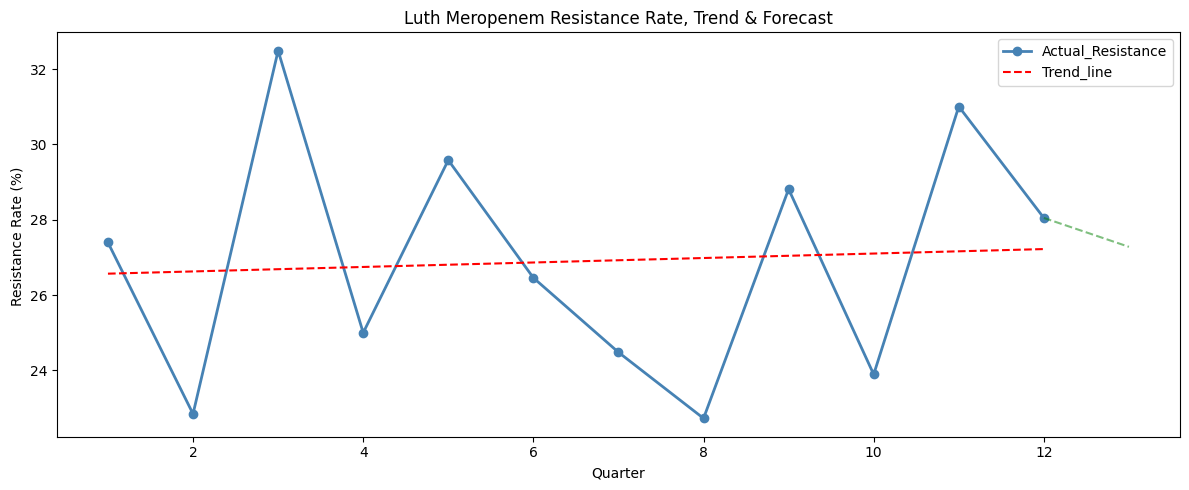

In [57]:
plt.figure(figsize = (12,5))
plt.plot(luth_meropenem["quarter_num"],luth_meropenem["resistance_rate"],
         label = "Actual_Resistance", color = "steelblue", linewidth=2, marker="o")
plt.plot(luth_meropenem["quarter_num"],luth_meropenem ["trend_line"],
         color = "red", label ="Trend_line", linestyle="--")
plt.plot([12, 13],
         [luth_meropenem["resistance_rate"].iloc[-1], future_predictions[0]],
         color="green", linestyle="--", alpha=0.5)
plt.xlabel("Quarter")
plt.ylabel("Resistance Rate (%) ")
plt.title("Luth Meropenem Resistance Rate, Trend & Forecast")
plt.legend()
plt.tight_layout()
plt.show()

Meropenem resistance at LUTH has remained stable between 22-32% over 12 quarters with no significant upward trend. Resistance is predicted to remain around 27% in Q1-Q2 2026 — suggesting current antimicrobial stewardship measures are containing but not reducing carbapenem resistance

In [58]:
from statsmodels.tsa.arima.model import ARIMA


resistance_series = luth_meropenem["resistance_rate"].values


arima_model = ARIMA(resistance_series, order=(1, 1, 1))
arima_fitted = arima_model.fit()


arima_forecast = arima_fitted.forecast(steps=2)

print(f"ARIMA Predictions:")
print(f"2026Q1 → {arima_forecast[0]:.2f}%")
print(f"2026Q2 → {arima_forecast[1]:.2f}%")
print(f"\nLinear Regression for comparison:")
print(f"2026Q1 → {future_predictions[0]:.2f}%")
print(f"2026Q2 → {future_predictions[1]:.2f}%")

ARIMA Predictions:
2026Q1 → 29.74%
2026Q2 → 28.55%

Linear Regression for comparison:
2026Q1 → 27.28%
2026Q2 → 27.34%


In [59]:
!pip install prophet --quiet

In [60]:
from prophet import Prophet
import pandas as pd


prophet_df = pd.DataFrame({
    "ds": pd.period_range(start="2023Q1", periods=12, freq="Q").to_timestamp(),
    "y": luth_meropenem["resistance_rate"].values
})


prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(prophet_df)


future = prophet_model.make_future_dataframe(periods=2, freq="QE")
forecast = prophet_model.predict(future)

print("Prophet Predictions:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(2))

INFO:prophet:n_changepoints greater than number of observations. Using 8.


Prophet Predictions:
           ds       yhat  yhat_lower  yhat_upper
12 2025-12-31  33.816447   32.754816   34.919956
13 2026-03-31  33.762597   32.718682   34.904257


In [61]:

mean = luth_meropenem["resistance_rate"].mean()
std = luth_meropenem["resistance_rate"].std()

luth_meropenem["is_anomaly"] = (
    luth_meropenem["resistance_rate"] > mean + 1.5*std
)

print(f"Mean resistance rate: {mean:.2f}%")
print(f"Standard deviation: {std:.2f}%")
print(f"Anomaly threshold: {mean + 1.5*std:.2f}%")
print()
print(luth_meropenem[["year_quarter", "resistance_rate", "is_anomaly"]])

Mean resistance rate: 26.90%
Standard deviation: 3.21%
Anomaly threshold: 31.71%

   year_quarter  resistance_rate  is_anomaly
0        2023Q1        27.397260       False
1        2023Q2        22.844828       False
2        2023Q3        32.489451        True
3        2023Q4        25.000000       False
4        2024Q1        29.583333       False
5        2024Q2        26.459144       False
6        2024Q3        24.481328       False
7        2024Q4        22.727273       False
8        2025Q1        28.813559       False
9        2025Q2        23.893805       False
10       2025Q3        31.007752       False
11       2025Q4        28.048780       False


In [62]:
from prophet import Prophet


anomaly_dates = prophet_df.loc[
    luth_meropenem["is_anomaly"].values, "ds"
].tolist()

print(f"Anomaly changepoints: {anomaly_dates}")

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=3,
    changepoints=anomaly_dates
)

prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=4, freq="QE")
forecast = prophet_model.predict(future)

print("\nProphet 2026 Predictions with Anomaly-informed Changepoints:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4))

Anomaly changepoints: [Timestamp('2023-07-01 00:00:00')]

Prophet 2026 Predictions with Anomaly-informed Changepoints:
           ds       yhat  yhat_lower  yhat_upper
12 2025-12-31  33.817273   32.788957   34.922329
13 2026-03-31  33.750948   32.636774   34.877412
14 2026-06-30  43.474358   42.346322   44.606344
15 2026-09-30  31.925614   30.879876   33.039478


In [63]:
prophet_model_3cp = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=3
)

prophet_model_3cp.fit(prophet_df)

future = prophet_model_3cp.make_future_dataframe(periods=4, freq="QE")
forecast_3cp = prophet_model_3cp.predict(future)

print("Prophet — n_changepoints=3, no anomaly detection:")
print(forecast_3cp[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(4))

Prophet — n_changepoints=3, no anomaly detection:
           ds       yhat  yhat_lower  yhat_upper
12 2025-12-31  33.814847   32.683998   34.879331
13 2026-03-31  33.751193   32.694196   34.738296
14 2026-06-30  43.469233   42.349071   44.471740
15 2026-09-30  31.921737   30.991791   32.997640


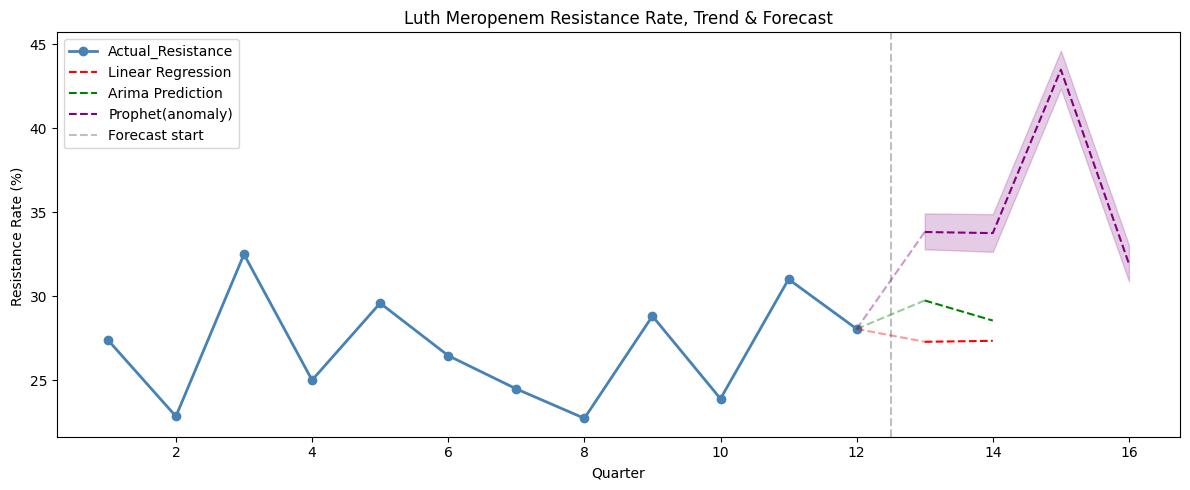

In [64]:
plt.figure(figsize=(12,5))
plt.plot(luth_meropenem["quarter_num"], luth_meropenem["resistance_rate"],
         label="Actual_Resistance", color = "steelblue", linewidth=2, marker="o")
plt.plot([13,14], future_predictions,
         label="Linear Regression", linestyle= "--", color="red")
plt.plot([13,14], arima_forecast, label="Arima Prediction", linestyle="--", color="green")
plt.plot([13,14,15,16], forecast["yhat"].tail(4),
         label="Prophet(anomaly)", color= "purple", linestyle="--")
plt.fill_between(
    [13, 14, 15, 16],
    forecast["yhat_lower"].tail(4),
    forecast["yhat_upper"].tail(4),
    alpha=0.2,
    color="purple"
)
plt.xlabel("Quarter")
plt.ylabel("Resistance Rate (%) ")
plt.title("Luth Meropenem Resistance Rate, Trend & Forecast")
plt.axvline(x=12.5, color="gray", linestyle="--", alpha=0.5, label="Forecast start")
last_actual = luth_meropenem["resistance_rate"].iloc[-1]
plt.plot([12, 13], [last_actual, future_predictions[0]], color="red", linestyle="--", alpha=0.4)
plt.plot([12, 13], [last_actual, arima_forecast[0]], color="green", linestyle="--", alpha=0.4)
plt.plot([12, 13], [last_actual, forecast["yhat"].tail(4).iloc[0]], color="purple", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Three forecasting models agree that LUTH Meropenem resistance will remain elevated in 2026, with estimates ranging from 27% (conservative) to 34% (moderate). Prophet's seasonal model projects a potential Q3 2026 spike to 43%, but with wide uncertainty, requiring clinical validation before acting on that signal.